In [2]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from time import perf_counter
import time


/Users/issei/Documents/CS202/lab/cmpsc202-lab01/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/Users/issei/Documents/CS202/lab/cmpsc202-lab01/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/Users/issei/Documents/CS202/lab/cmpsc202-lab01/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/Users/issei/Documents/CS202/lab/cmpsc202-lab01/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
def baseline_max_sublist(arr):
    max_so_far = -100000000000
    for i in range(0, len(arr)):
        current_sum = 0
        for j in range(i, len(arr)):
            current_sum = current_sum + arr[j]
            if current_sum > max_so_far:
                max_so_far = current_sum
    return max_so_far






In [4]:
def kadane_max_sublist(arr):
    max_so_far = -10000000000000000
    current_max = 0
    for i in range(0, len(arr)):
        current_max = current_max + arr[i]
        if current_max > max_so_far:
            max_so_far = current_max
        if current_max < 0:
            current_max = 0
    
    return max_so_far


In [5]:
def helper_generate_random_arr(n):
    arr = np.random.randint(-100, 101, size=n)

    if not np.any(arr < 0):
        arr[0] = -1

    if not np.any(arr > 0):
        arr[1] = 1

    return arr.tolist()

In [6]:
sizes = [100, 500, 1000, 2500, 5000, 10000]
trials = 5
base_list = []
kadane = []

for n in sizes:
    for _ in range(trials):
        test_arr = helper_generate_random_arr(n)
        baseline_max_sublist(test_arr)
        kadane_max_sublist(test_arr)





N = 100: Baseline = 0.000094s, Kadane = 0.000003s
N = 500: Baseline = 0.002776s, Kadane = 0.000014s
N = 1000: Baseline = 0.012203s, Kadane = 0.000029s
N = 2500: Baseline = 0.079249s, Kadane = 0.000095s
N = 5000: Baseline = 0.305523s, Kadane = 0.000143s
N = 10000: Baseline = 1.226751s, Kadane = 0.000282s


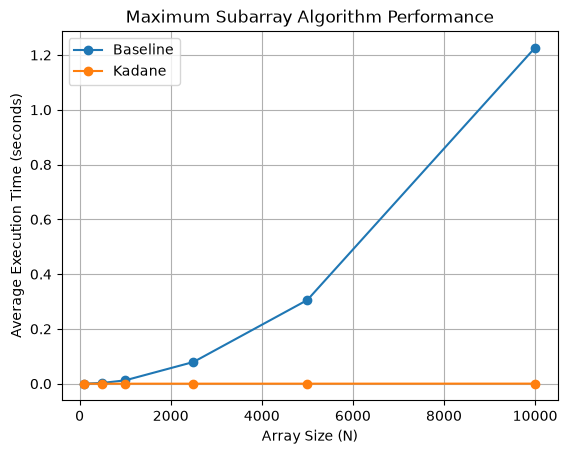

In [ ]:
sizes = [100, 500, 1000, 2500, 5000, 10000]
num_trials = 5

baseline_times = []
kadane_times = []


for n in sizes:
    baseline_total = 0
    kadane_total = 0

    for _ in range(num_trials):
        arr = helper_generate_random_arr(n)

        start = time.perf_counter()
        baseline_result = baseline_max_sublist(arr)
        end = time.perf_counter()

        baseline_total += end - start

        start = time.perf_counter()
        kadane_result = kadane_max_sublist(arr)
        end = time.perf_counter()

        kadane_total += end - start

        assert baseline_result == kadane_result

    baseline_average = baseline_total / num_trials
    kadane_average = kadane_total / num_trials

    baseline_times.append(baseline_average)
    kadane_times.append(kadane_average)

    print(
        f"N = {n}: "
        f"Baseline = {baseline_average:.6f}s, "
        f"Kadane = {kadane_average:.6f}s"
    )


plt.plot(
    sizes,
    baseline_times,
    marker="o",
    label="Baseline"
)

plt.plot(
    sizes,
    kadane_times,
    marker="o",
    label="Kadane"
)

plt.xlabel("Array Size (N)")
plt.ylabel("Average Execution Time (seconds)")
plt.title("Maximum Subarray Algorithm Performance")

plt.legend()
plt.grid()

plt.show()